In [3]:
import sys
import pandas as pd
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Pandas: 2.2.3
NumPy: 2.1.3
SciPy: 1.16.3
Matplotlib: 3.10.0


In [4]:
clinical = pd.read_csv(
    "/content/TCGA.GBMLGG.sampleMap_GBMLGG_clinicalMatrix",
    sep="\t",
    index_col=0,
    low_memory=False
)

expression = pd.read_csv(
    "/content/TCGA.GBMLGG.sampleMap_HiSeqV2.gz",
    sep="\t",
    compression="gzip",
    index_col=0,
    low_memory=False
)

print("Clinical shape:", clinical.shape)
print("Expression shape:", expression.shape)

Clinical shape: (1148, 115)
Expression shape: (20530, 702)


In [5]:
# Remove the stray header-like row if present
clinical = clinical.loc[clinical.index != "sampleID"].copy()

# Match clinical records to expression samples
matched_clinical = clinical.loc[
    clinical.index.intersection(expression.columns)
].copy()
matched_clinical = matched_clinical.reindex(expression.columns)

# Keep only Primary Tumor samples
primary_mask = matched_clinical["sample_type"].eq("Primary Tumor")
primary_clinical = matched_clinical.loc[primary_mask].copy()

# Keep only the two disease groups being compared
disease_mask = primary_clinical["_primary_disease"].isin([
    "brain lower grade glioma",
    "glioblastoma multiforme"
])
primary_clinical = primary_clinical.loc[disease_mask].copy()

# Align expression columns to the filtered clinical samples
primary_expression = expression.loc[:, primary_clinical.index]

print("Primary tumor expression shape:", primary_expression.shape)
print("\nSamples per disease group:")
print(primary_clinical["_primary_disease"].value_counts())
print("\nSample order matches:",
      primary_expression.columns.equals(primary_clinical.index))

Primary tumor expression shape: (20530, 670)

Samples per disease group:
_primary_disease
brain lower grade glioma    516
glioblastoma multiforme     154
Name: count, dtype: int64

Sample order matches: True


In [6]:
lgg_samples = primary_clinical.index[
    primary_clinical["_primary_disease"] == "brain lower grade glioma"
]
gbm_samples = primary_clinical.index[
    primary_clinical["_primary_disease"] == "glioblastoma multiforme"
]

print("LGG samples:", len(lgg_samples))
print("GBM samples:", len(gbm_samples))

LGG samples: 516
GBM samples: 154


In [7]:
candidate_genes = [
    "NLRP3", "PYCARD", "CASP1", "IL1B", "IL18",
    "TLR4", "TNF", "CXCL10", "AIF1", "CSF1R"
]

effect_results = []
for gene in candidate_genes:
    lgg = primary_expression.loc[gene, lgg_samples].dropna().to_numpy()
    gbm = primary_expression.loc[gene, gbm_samples].dropna().to_numpy()

    U, p = mannwhitneyu(
        lgg, gbm,
        alternative="two-sided",
        method="asymptotic"
    )

    # Positive delta = higher values tend toward GBM
    cliffs_delta = 1 - (2 * U / (len(lgg) * len(gbm)))

    effect_results.append({
        "Gene": gene,
        "LGG_n": len(lgg),
        "GBM_n": len(gbm),
        "LGG_median": np.median(lgg),
        "GBM_median": np.median(gbm),
        "Median_difference_GBM_minus_LGG": np.median(gbm) - np.median(lgg),
        "U_statistic": U,
        "Cliffs_delta": cliffs_delta,
        "P_value": p
    })

effect_df = pd.DataFrame(effect_results)
effect_df["Adjusted_p_value"] = multipletests(
    effect_df["P_value"], method="fdr_bh"
)[1]
effect_df = effect_df.sort_values("Adjusted_p_value").reset_index(drop=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.10g}")
display(effect_df)

,Gene,LGG_n,GBM_n,LGG_median,GBM_median,Median_difference_GBM_minus_LGG,U_statistic,Cliffs_delta,P_value,Adjusted_p_value
0,CXCL10,516,154,3.24335,7.63465,4.3913,8020,0.7981475888,3.784614131e-51,3.784614131e-50
1,CASP1,516,154,6.9028,8.5955,1.6927,14159,0.6436373704,7.184997935e-34,3.592498967e-33
2,PYCARD,516,154,6.9668,8.18345,1.21665,16613,0.5818735528,5.482419427e-28,1.827473142e-27
3,IL18,516,154,7.0878,8.25035,1.16255,21068.5,0.4697347226,8.465169793e-19,2.116292448e-18
4,AIF1,516,154,9.03325,9.90385,0.8706,24570,0.3816067653,6.35657208e-13,1.271314416e-12
5,IL1B,516,154,6.1417,7.44115,1.29945,25533,0.3573693748,1.630747452e-11,2.717912419e-11
6,TLR4,516,154,9.8589,9.5708,-0.2881,47186.5,-0.187619551,0.0004059680742,0.0005799543918
7,TNF,516,154,4.61625,4.2833,-0.33295,42642.5,-0.07325329709,0.167432019,0.2092900238
8,NLRP3,516,154,7.0903,7.03955,-0.05075,42228.5,-0.06283348435,0.2363730867,0.262636763
9,CSF1R,516,154,11.56325,11.66305,0.0998,38270,0.0367965368,0.4880994877,0.4880994877


In [8]:
from pathlib import Path

output_dir = Path("/content/TCGA_Neuroinflammation_Project/results")
output_dir.mkdir(parents=True, exist_ok=True)

results_path = output_dir / "LGG_vs_GBM_gene_statistics.csv"
effect_df.to_csv(results_path, index=False)

print("Saved:", results_path)

Saved: /content/TCGA_Neuroinflammation_Project/results/LGG_vs_GBM_gene_statistics.csv


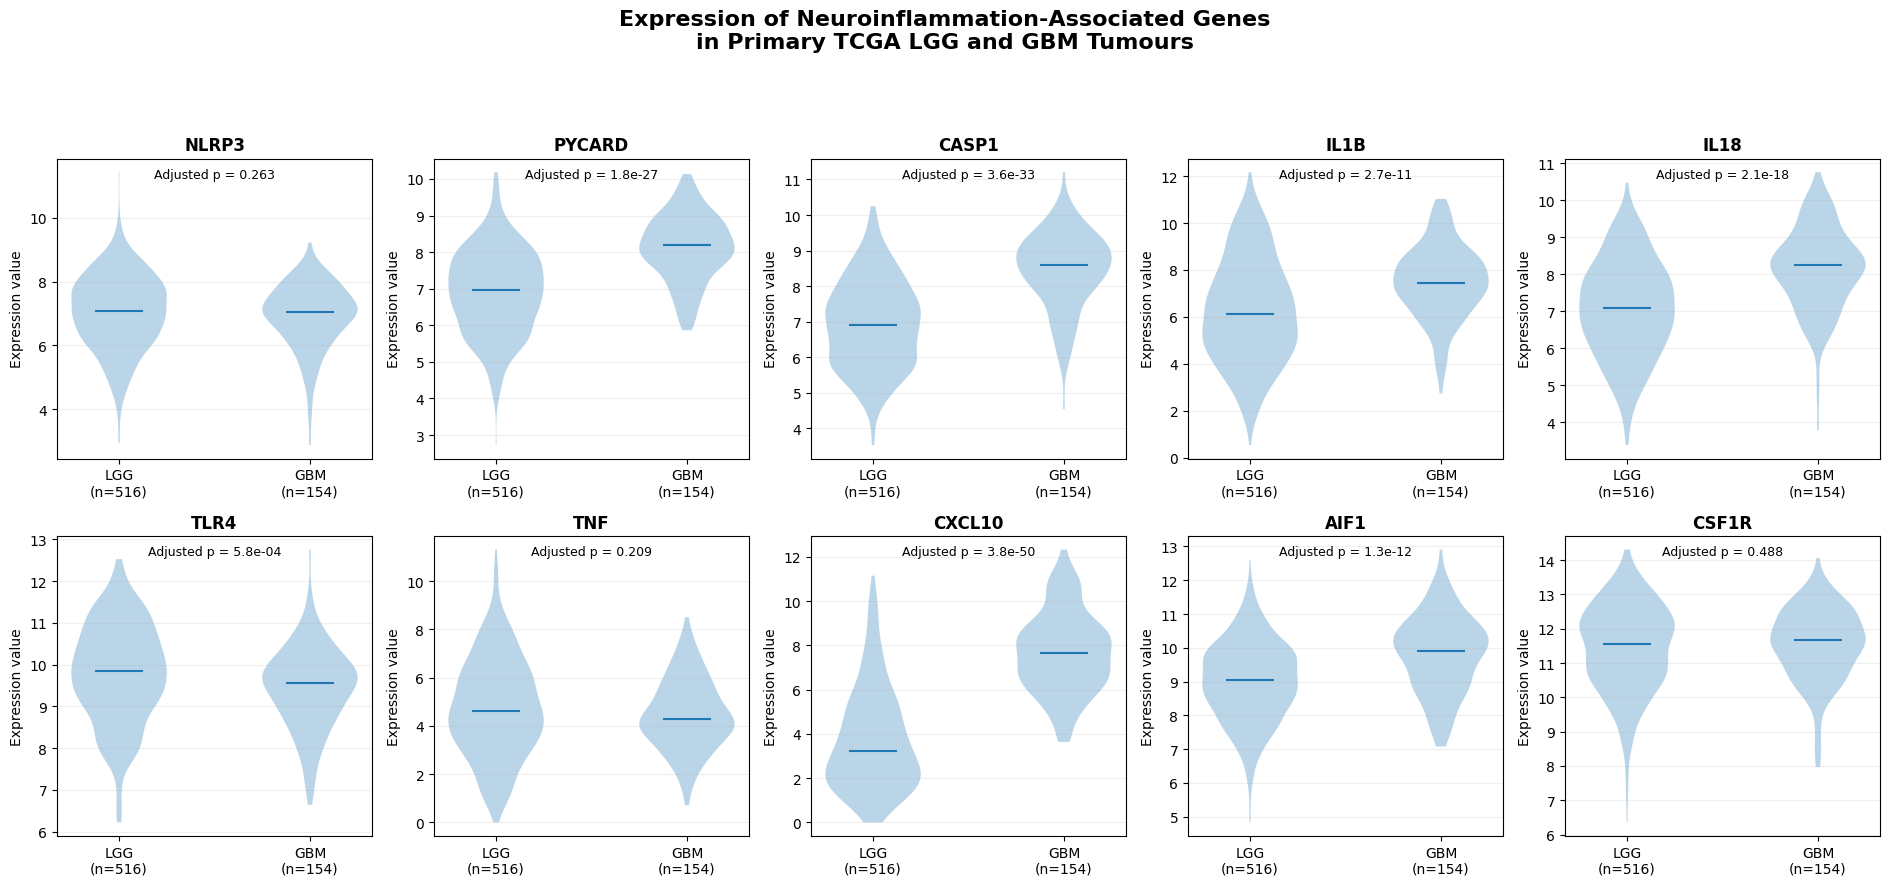

Saved: /content/TCGA_Neuroinflammation_Project/results/candidate_gene_expression_LGG_vs_GBM_FINAL.png


In [9]:
fig, axes = plt.subplots(2, 5, figsize=(19, 9))
axes = axes.flatten()

for ax, gene in zip(axes, candidate_genes):
    lgg = primary_expression.loc[gene, lgg_samples].dropna().to_numpy()
    gbm = primary_expression.loc[gene, gbm_samples].dropna().to_numpy()

    ax.violinplot(
        [lgg, gbm],
        positions=[1, 2],
        showmedians=True,
        showextrema=False
    )
    ax.set_xticks([1, 2])
    ax.set_xticklabels([f"LGG\n(n={len(lgg)})", f"GBM\n(n={len(gbm)})"])
    ax.set_title(gene, fontweight="bold")
    ax.set_ylabel("Expression value")
    ax.grid(axis="y", alpha=0.2)

    adj_p = effect_df.loc[effect_df["Gene"] == gene, "Adjusted_p_value"].iloc[0]
    p_label = f"Adjusted p = {adj_p:.1e}" if adj_p < 0.001 else f"Adjusted p = {adj_p:.3f}"
    ax.text(0.5, 0.97, p_label, transform=ax.transAxes,
            ha="center", va="top", fontsize=9)

fig.suptitle(
    "Expression of Neuroinflammation-Associated Genes\nin Primary TCGA LGG and GBM Tumours",
    fontsize=16, fontweight="bold"
)
fig.tight_layout(rect=[0, 0, 1, 0.92])

figure_path = output_dir / "candidate_gene_expression_LGG_vs_GBM_FINAL.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
backup_dir = Path("/content/drive/MyDrive/TCGA_Neuroinflammation_Project")
backup_dir.mkdir(parents=True, exist_ok=True)

shutil.copy2(results_path, backup_dir)
shutil.copy2(figure_path, backup_dir)
print("Backed up to:", backup_dir)

Mounted at /content/drive
Backed up to: /content/drive/MyDrive/TCGA_Neuroinflammation_Project


In [11]:
import statsmodels

print(statsmodels.__version__)

0.15.0


In [12]:
# ============================================================
# 3C - Independent validation using CGGA mRNAseq_693
# ============================================================

import zipfile
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# File paths
# ------------------------------------------------------------

clinical_zip = "/content/CGGA.mRNAseq_693_clinical.20200506.txt.zip"
expression_zip = "/content/CGGA.mRNAseq_693.RSEM-genes.20200506.txt (1).zip"

# ------------------------------------------------------------
# Read the two CGGA files directly from their ZIP archives
# ------------------------------------------------------------

with zipfile.ZipFile(clinical_zip) as z:
    clinical_file = [
        name for name in z.namelist()
        if name.endswith(".txt") and not name.startswith("__MACOSX")
    ][0]

    with z.open(clinical_file) as f:
        clinical = pd.read_csv(f, sep="\t")

with zipfile.ZipFile(expression_zip) as z:
    expression_file = [
        name for name in z.namelist()
        if name.endswith(".txt") and not name.startswith("__MACOSX")
    ][0]

    with z.open(expression_file) as f:
        expression = pd.read_csv(f, sep="\t")

print("Clinical shape:", clinical.shape)
print("Expression shape:", expression.shape)

# ------------------------------------------------------------
# Define the same 10-gene panel used in the TCGA analysis
# ------------------------------------------------------------

genes = [
    "NLRP3",
    "PYCARD",
    "CASP1",
    "IL1B",
    "IL18",
    "TLR4",
    "TNF",
    "CXCL10",
    "AIF1",
    "CSF1R"
]

# ------------------------------------------------------------
# Keep primary tumors only
# ------------------------------------------------------------

primary = clinical[clinical["PRS_type"].astype(str).str.strip() == "Primary"].copy()

# Define LGG = WHO II + WHO III
# Define GBM = WHO IV
primary = primary[
    primary["Grade"].astype(str).str.strip().isin(
        ["WHO II", "WHO III", "WHO IV"]
    )
].copy()

primary["Group"] = np.where(
    primary["Grade"].astype(str).str.strip().isin(["WHO II", "WHO III"]),
    "LGG",
    "GBM"
)

print("\nPrimary samples:")
print(primary["Group"].value_counts())
print("\nGrade counts:")
print(primary["Grade"].value_counts())

# ------------------------------------------------------------
# Check clinical-expression sample matching
# ------------------------------------------------------------

clinical_ids = set(primary["CGGA_ID"].astype(str))
expression_ids = set(expression.columns[1:].astype(str))

matched_ids = sorted(clinical_ids & expression_ids)

print("\nPrimary clinical IDs:", len(clinical_ids))
print("Expression sample IDs:", len(expression_ids))
print("Matched primary IDs:", len(matched_ids))

# ------------------------------------------------------------
# Prepare expression matrix
# ------------------------------------------------------------

expr = expression.set_index("Gene_Name")

# Keep only the 10 genes
missing_genes = [g for g in genes if g not in expr.index]

if missing_genes:
    raise ValueError(f"Missing genes from CGGA expression matrix: {missing_genes}")

expr10 = expr.loc[genes, matched_ids].apply(pd.to_numeric, errors="coerce")

# ------------------------------------------------------------
# Align clinical information to expression columns
# ------------------------------------------------------------

clinical_subset = (
    primary.set_index("CGGA_ID")
    .loc[matched_ids]
)

# ------------------------------------------------------------
# Run the same statistical framework as TCGA
# ------------------------------------------------------------

results = []

for gene in genes:

    lgg_ids = clinical_subset.index[
        clinical_subset["Group"] == "LGG"
    ]

    gbm_ids = clinical_subset.index[
        clinical_subset["Group"] == "GBM"
    ]

    lgg = expr10.loc[gene, lgg_ids].dropna().values
    gbm = expr10.loc[gene, gbm_ids].dropna().values

    # Two-sided Mann-Whitney U, same asymptotic method as TCGA
    U, p = mannwhitneyu(
        lgg,
        gbm,
        alternative="two-sided",
        method="asymptotic"
    )

    # Cliff's delta oriented GBM minus LGG
    delta = 1 - (2 * U / (len(lgg) * len(gbm)))

    results.append({
        "Gene": gene,
        "LGG_n": len(lgg),
        "GBM_n": len(gbm),
        "LGG_median": np.median(lgg),
        "GBM_median": np.median(gbm),
        "Median_difference_GBM_minus_LGG":
            np.median(gbm) - np.median(lgg),
        "Cliffs_delta_GBM_minus_LGG": delta,
        "Raw_p": p
    })

cgga_results = pd.DataFrame(results)

# ------------------------------------------------------------
# Benjamini-Hochberg correction across the 10 genes
# ------------------------------------------------------------

cgga_results["Adjusted_p"] = multipletests(
    cgga_results["Raw_p"],
    method="fdr_bh"
)[1]

# ------------------------------------------------------------
# Sort by adjusted p-value
# ------------------------------------------------------------

cgga_results = cgga_results.sort_values(
    "Adjusted_p"
).reset_index(drop=True)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6g}")

print("\nCGGA validation results:")
display(cgga_results)

Clinical shape: (693, 13)
Expression shape: (23987, 694)

Primary samples:
Group
LGG    282
GBM    140
Name: count, dtype: int64

Grade counts:
Grade
WHO III    144
WHO IV     140
WHO II     138
Name: count, dtype: int64

Primary clinical IDs: 422
Expression sample IDs: 693
Matched primary IDs: 422

CGGA validation results:


,Gene,LGG_n,GBM_n,LGG_median,GBM_median,Median_difference_GBM_minus_LGG,Cliffs_delta_GBM_minus_LGG,Raw_p,Adjusted_p
0,CXCL10,282,140,0.27,1.465,1.195,0.453901,3.02322e-14,3.02322e-13
1,IL1B,282,140,1.53,2.855,1.325,0.261221,1.23865e-05,6.19324e-05
2,CASP1,282,140,6.475,9.015,2.54,0.212335,0.000381393,0.00127131
3,TLR4,282,140,2.435,2.215,-0.22,-0.117224,0.0498651,0.11539
4,TNF,282,140,0.795,0.78,-0.015,-0.11345,0.0576952,0.11539
5,IL18,282,140,7.355,9.41,2.055,0.100785,0.0917884,0.152981
6,NLRP3,282,140,1.54,1.45,-0.09,-0.0662361,0.267892,0.316994
7,PYCARD,282,140,19.445,23.08,3.635,0.0717072,0.230346,0.316994
8,CSF1R,282,140,21.855,21.435,-0.42,-0.0638804,0.285294,0.316994
9,AIF1,282,140,69.595,78.11,8.515,0.0299899,0.616088,0.616088


In [17]:
# Find the CGGA results DataFrame
for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        print(name, obj.shape)
        print(list(obj.columns))
        print()

clinical (693, 13)
['CGGA_ID', 'PRS_type', 'Histology', 'Grade', 'Gender', 'Age', 'OS', 'Censor (alive=0; dead=1)', 'Radio_status (treated=1;un-treated=0)', 'Chemo_status (TMZ treated=1;un-treated=0)', 'IDH_mutation_status', '1p19q_codeletion_status', 'MGMTp_methylation_status']

expression (23987, 694)
['Gene_Name', 'CGGA_1002', 'CGGA_1003', 'CGGA_1010', 'CGGA_1012', 'CGGA_1014', 'CGGA_1017', 'CGGA_1018', 'CGGA_103', 'CGGA_1030', 'CGGA_1032', 'CGGA_1033', 'CGGA_1036', 'CGGA_1037', 'CGGA_1041', 'CGGA_1048', 'CGGA_1051', 'CGGA_1055', 'CGGA_1057', 'CGGA_1058', 'CGGA_106', 'CGGA_1063', 'CGGA_1065', 'CGGA_1066', 'CGGA_1069', 'CGGA_107', 'CGGA_1075', 'CGGA_108', 'CGGA_1082', 'CGGA_1086', 'CGGA_1087', 'CGGA_1097', 'CGGA_1100', 'CGGA_1101', 'CGGA_1103', 'CGGA_1106', 'CGGA_1108', 'CGGA_1111', 'CGGA_112', 'CGGA_1120', 'CGGA_1121', 'CGGA_1126', 'CGGA_1127', 'CGGA_1130', 'CGGA_1131', 'CGGA_1132', 'CGGA_1134', 'CGGA_1135', 'CGGA_1137', 'CGGA_1138', 'CGGA_1141', 'CGGA_1142', 'CGGA_1144', 'CGGA_1147

In [19]:
# Step 3D - Recreate CGGA validation results with correct sample IDs

cgga_effect_results = []

lgg_samples_cgga = primary.loc[
    primary["Group"] == "LGG", "CGGA_ID"
].tolist()

gbm_samples_cgga = primary.loc[
    primary["Group"] == "GBM", "CGGA_ID"
].tolist()

for gene in candidate_genes:
    lgg = expr.loc[gene, lgg_samples_cgga].dropna().to_numpy()
    gbm = expr.loc[gene, gbm_samples_cgga].dropna().to_numpy()

    U, p = mannwhitneyu(
        lgg,
        gbm,
        alternative="two-sided",
        method="asymptotic"
    )

    cliffs_delta = 1 - (2 * U / (len(lgg) * len(gbm)))

    cgga_effect_results.append({
        "Gene": gene,
        "LGG_n": len(lgg),
        "GBM_n": len(gbm),
        "LGG_median": np.median(lgg),
        "GBM_median": np.median(gbm),
        "Median_difference_GBM_minus_LGG": np.median(gbm) - np.median(lgg),
        "U_statistic": U,
        "Cliffs_delta": cliffs_delta,
        "P_value": p
    })

cgga_effect_df = pd.DataFrame(cgga_effect_results)

cgga_effect_df["Adjusted_p_value"] = multipletests(
    cgga_effect_df["P_value"],
    method="fdr_bh"
)[1]

cgga_effect_df = cgga_effect_df.sort_values(
    "Adjusted_p_value"
).reset_index(drop=True)

display(cgga_effect_df)

,Gene,LGG_n,GBM_n,LGG_median,GBM_median,Median_difference_GBM_minus_LGG,U_statistic,Cliffs_delta,P_value,Adjusted_p_value
0,CXCL10,282,140,0.27,1.465,1.195,10780,0.453901,3.02322e-14,3.02322e-13
1,IL1B,282,140,1.53,2.855,1.325,14583.5,0.261221,1.23865e-05,6.19324e-05
2,CASP1,282,140,6.475,9.015,2.54,15548.5,0.212335,0.000381393,0.00127131
3,TLR4,282,140,2.435,2.215,-0.22,22054,-0.117224,0.0498651,0.11539
4,TNF,282,140,0.795,0.78,-0.015,21979.5,-0.11345,0.0576952,0.11539
5,IL18,282,140,7.355,9.41,2.055,17750.5,0.100785,0.0917884,0.152981
6,NLRP3,282,140,1.54,1.45,-0.09,21047.5,-0.0662361,0.267892,0.316994
7,PYCARD,282,140,19.445,23.08,3.635,18324.5,0.0717072,0.230346,0.316994
8,CSF1R,282,140,21.855,21.435,-0.42,21001,-0.0638804,0.285294,0.316994
9,AIF1,282,140,69.595,78.11,8.515,19148,0.0299899,0.616088,0.616088


In [20]:
# Compare TCGA and CGGA validation results

comparison = effect_df[
    ["Gene", "Median_difference_GBM_minus_LGG",
     "Cliffs_delta", "Adjusted_p_value"]
].copy()

comparison = comparison.rename(columns={
    "Median_difference_GBM_minus_LGG": "TCGA_median_diff",
    "Cliffs_delta": "TCGA_cliffs_delta",
    "Adjusted_p_value": "TCGA_adjusted_p"
})

cgga_compare = cgga_effect_df[
    ["Gene", "Median_difference_GBM_minus_LGG",
     "Cliffs_delta", "Adjusted_p_value"]
].copy()

cgga_compare = cgga_compare.rename(columns={
    "Median_difference_GBM_minus_LGG": "CGGA_median_diff",
    "Cliffs_delta": "CGGA_cliffs_delta",
    "Adjusted_p_value": "CGGA_adjusted_p"
})

comparison = comparison.merge(cgga_compare, on="Gene")

comparison["TCGA_direction"] = np.where(
    comparison["TCGA_cliffs_delta"] > 0,
    "Higher in GBM",
    "Higher in LGG"
)

comparison["CGGA_direction"] = np.where(
    comparison["CGGA_cliffs_delta"] > 0,
    "Higher in GBM",
    "Higher in LGG"
)

comparison["Same_direction"] = (
    comparison["TCGA_direction"] == comparison["CGGA_direction"]
)

comparison["TCGA_significant"] = comparison["TCGA_adjusted_p"] < 0.05
comparison["CGGA_significant"] = comparison["CGGA_adjusted_p"] < 0.05

def classify(row):
    if not row["Same_direction"]:
        return "Opposite direction"
    elif row["TCGA_significant"] and row["CGGA_significant"]:
        return "Significant replication"
    elif row["TCGA_significant"] and not row["CGGA_significant"]:
        return "Same direction, not significant in CGGA"
    else:
        return "Same direction, neither significant"

comparison["Validation_result"] = comparison.apply(
    classify,
    axis=1
)

comparison = comparison.sort_values(
    ["Validation_result", "TCGA_adjusted_p"]
).reset_index(drop=True)

display(comparison)

,Gene,TCGA_median_diff,TCGA_cliffs_delta,TCGA_adjusted_p,CGGA_median_diff,CGGA_cliffs_delta,CGGA_adjusted_p,TCGA_direction,CGGA_direction,Same_direction,TCGA_significant,CGGA_significant,Validation_result
0,CSF1R,0.0998,0.0367965,0.488099,-0.42,-0.0638804,0.316994,Higher in GBM,Higher in LGG,False,False,False,Opposite direction
1,TNF,-0.33295,-0.0732533,0.20929,-0.015,-0.11345,0.11539,Higher in LGG,Higher in LGG,True,False,False,"Same direction, neither significant"
2,NLRP3,-0.05075,-0.0628335,0.262637,-0.09,-0.0662361,0.316994,Higher in LGG,Higher in LGG,True,False,False,"Same direction, neither significant"
3,PYCARD,1.21665,0.581874,1.82747e-27,3.635,0.0717072,0.316994,Higher in GBM,Higher in GBM,True,True,False,"Same direction, not significant in CGGA"
4,IL18,1.16255,0.469735,2.11629e-18,2.055,0.100785,0.152981,Higher in GBM,Higher in GBM,True,True,False,"Same direction, not significant in CGGA"
5,AIF1,0.8706,0.381607,1.27131e-12,8.515,0.0299899,0.616088,Higher in GBM,Higher in GBM,True,True,False,"Same direction, not significant in CGGA"
6,TLR4,-0.2881,-0.18762,0.000579954,-0.22,-0.117224,0.11539,Higher in LGG,Higher in LGG,True,True,False,"Same direction, not significant in CGGA"
7,CXCL10,4.3913,0.798148,3.78461e-50,1.195,0.453901,3.02322e-13,Higher in GBM,Higher in GBM,True,True,True,Significant replication
8,CASP1,1.6927,0.643637,3.5925e-33,2.54,0.212335,0.00127131,Higher in GBM,Higher in GBM,True,True,True,Significant replication
9,IL1B,1.29945,0.357369,2.71791e-11,1.325,0.261221,6.19324e-05,Higher in GBM,Higher in GBM,True,True,True,Significant replication


In [21]:
# Step 4A - Inspect potentially relevant TCGA clinical variables

possible_covariates = [
    "age_at_initial_pathologic_diagnosis",
    "gender",
    "race",
    "ethnicity",
    "histological_type",
    "neoplasm_histologic_grade",
    "tumor_stage",
    "pathologic_stage",
    "sample_type"
]

available_covariates = [
    col for col in possible_covariates
    if col in primary_clinical.columns
]

print("Available candidate covariates:")
print(available_covariates)

print("\nUnique values / missingness:")
for col in available_covariates:
    print(f"\n--- {col} ---")
    print("Missing:", primary_clinical[col].isna().sum())
    print(primary_clinical[col].value_counts(dropna=False).head(15))

Available candidate covariates:
['age_at_initial_pathologic_diagnosis', 'gender', 'histological_type', 'neoplasm_histologic_grade', 'sample_type']

Unique values / missingness:

--- age_at_initial_pathologic_diagnosis ---
Missing: 2
age_at_initial_pathologic_diagnosis
38    22
30    21
59    18
33    18
34    17
48    17
31    17
62    17
36    17
43    17
53    16
54    16
47    15
52    15
32    15
Name: count, dtype: int64

--- gender ---
Missing: 2
gender
MALE      384
FEMALE    284
NaN         2
Name: count, dtype: int64

--- histological_type ---
Missing: 2
histological_type
Astrocytoma                        194
Oligodendroglioma                  191
Untreated primary (de novo) GBM    151
Oligoastrocytoma                   130
NaN                                  2
Treated primary GBM                  1
Glioblastoma Multiforme (GBM)        1
Name: count, dtype: int64

--- neoplasm_histologic_grade ---
Missing: 155
neoplasm_histologic_grade
G3               265
G2               2

In [23]:
# Step 4B - Check age and gender by TCGA tumor group

covariate_check = primary_clinical[
    ["sample_type", "age_at_initial_pathologic_diagnosis", "gender"]
].copy()

# Start with an object-type column so strings and missing values work
covariate_check["Group"] = pd.Series(
    index=covariate_check.index,
    dtype="object"
)

covariate_check.loc[
    covariate_check.index.isin(lgg_samples),
    "Group"
] = "LGG"

covariate_check.loc[
    covariate_check.index.isin(gbm_samples),
    "Group"
] = "GBM"

print("Group counts:")
print(covariate_check["Group"].value_counts(dropna=False))

print("\nAge summary by group:")
print(
    covariate_check.groupby("Group")[
        "age_at_initial_pathologic_diagnosis"
    ].describe()
)

print("\nGender by group:")
print(
    pd.crosstab(
        covariate_check["Group"],
        covariate_check["gender"],
        margins=True
    )
)

Group counts:
Group
LGG    516
GBM    154
Name: count, dtype: int64

Age summary by group:
       count    mean     std  min  25%  50%  75%  max
Group                                                
GBM      153 59.8366 13.5416   21   52   60   70   89
LGG      515 42.9417 13.3557   14   32   41   53   87

Gender by group:
gender  FEMALE  MALE  All
Group                    
GBM         54    99  153
LGG        230   285  515
All        284   384  668


In [24]:
# Step 4C - Age- and gender-adjusted sensitivity analysis
#
# Model:
# Gene expression ~ tumor group + age + gender

import statsmodels.formula.api as smf

adjusted_results = []

# Build analysis dataframe
analysis_df = primary_clinical[
    ["age_at_initial_pathologic_diagnosis", "gender"]
].copy()

analysis_df["Group"] = np.nan
analysis_df.loc[
    analysis_df.index.isin(lgg_samples), "Group"
] = "LGG"
analysis_df.loc[
    analysis_df.index.isin(gbm_samples), "Group"
] = "GBM"

# Keep only complete clinical records
analysis_df = analysis_df.dropna(
    subset=["Group", "age_at_initial_pathologic_diagnosis", "gender"]
)

# Make GBM the reference comparison against LGG
analysis_df["Group"] = pd.Categorical(
    analysis_df["Group"],
    categories=["LGG", "GBM"]
)

# Add expression values for each gene
for gene in candidate_genes:

    gene_expression = primary_expression.loc[
        gene, analysis_df.index
    ]

    model_df = analysis_df.copy()
    model_df["Expression"] = gene_expression.values

    model_df = model_df.dropna(subset=["Expression"])

    model = smf.ols(
        "Expression ~ C(Group) + age_at_initial_pathologic_diagnosis + C(gender)",
        data=model_df
    ).fit()

    adjusted_results.append({
        "Gene": gene,
        "N": len(model_df),
        "Adjusted_GBM_coefficient": model.params.get("C(Group)[T.GBM]", np.nan),
        "Adjusted_GBM_p": model.pvalues.get("C(Group)[T.GBM]", np.nan),
        "Age_coefficient": model.params.get(
            "age_at_initial_pathologic_diagnosis", np.nan
        ),
        "Gender_Male_coefficient": model.params.get(
            "C(gender)[T.MALE]", np.nan
        )
    })

adjusted_df = pd.DataFrame(adjusted_results)

# Correct for testing the 10 genes
adjusted_df["Adjusted_p_BH"] = multipletests(
    adjusted_df["Adjusted_GBM_p"],
    method="fdr_bh"
)[1]

adjusted_df = adjusted_df.sort_values(
    "Adjusted_p_BH"
).reset_index(drop=True)

display(adjusted_df)

/tmp/ipykernel_2192/2295836115.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'LGG' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  analysis_df.loc[


,Gene,N,Adjusted_GBM_coefficient,Adjusted_GBM_p,Age_coefficient,Gender_Male_coefficient,Adjusted_p_BH
0,CXCL10,668,3.47284,7.84782e-45,0.0269302,0.135199,7.84782e-44
1,CASP1,668,1.46517,2.66833e-28,0.0032118,0.0606081,1.33416e-27
2,PYCARD,668,1.23018,2.29905e-24,-0.00202122,0.046057,7.6635e-24
3,IL18,668,1.0981,9.7969e-16,-0.00145881,0.0533743,2.44923e-15
4,AIF1,668,0.965415,1.30046e-14,-0.0094828,0.0637635,2.60091e-14
5,IL1B,668,1.40015,2.35745e-10,-0.0107814,0.148809,3.92909e-10
6,CSF1R,668,0.384415,0.00271567,-0.0170034,0.0119798,0.00387953
7,TLR4,668,-0.138145,0.245915,-0.012801,0.0400451,0.307394
8,NLRP3,668,0.0435215,0.715288,-0.0107996,0.0222317,0.794764
9,TNF,668,-0.0442956,0.824708,-0.0152448,0.397965,0.824708


In [25]:
# Step 4D - Basic residual diagnostics for the three replicated genes

diagnostic_results = []

for gene in ["CXCL10", "CASP1", "IL1B"]:

    model_df = analysis_df.copy()

    model_df["Expression"] = primary_expression.loc[
        gene, model_df.index
    ].values

    model_df = model_df.dropna(subset=["Expression"])

    model = smf.ols(
        "Expression ~ C(Group) + age_at_initial_pathologic_diagnosis + C(gender)",
        data=model_df
    ).fit()

    diagnostic_results.append({
        "Gene": gene,
        "N": len(model_df),
        "R_squared": model.rsquared,
        "Adjusted_R_squared": model.rsquared_adj,
        "Residual_mean": model.resid.mean(),
        "Residual_SD": model.resid.std()
    })

diagnostic_df = pd.DataFrame(diagnostic_results)

display(diagnostic_df)

,Gene,N,R_squared,Adjusted_R_squared,Residual_mean,Residual_SD
0,CXCL10,668,0.376464,0.373647,-5.23015e-14,2.18359
1,CASP1,668,0.220883,0.217363,1.59819e-14,1.20841
2,IL1B,668,0.0642051,0.0599771,2.04786e-14,2.07477
